In [3]:
# ==========================================
# 1. Import Libraries
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report

In [4]:
# ==========================================
# 2. Load Dataset & Basic Understanding
# ==========================================
# Replace "A.csv" with your actual data file path if different
df = pd.read_csv("A.csv")

print("Data Shape:", df.shape)
# df.info()
# df.describe()


Data Shape: (300, 83)


In [5]:
# ==========================================
# 3. Missing Value Analysis
# ==========================================
# Drop columns that are completely empty
df.dropna(axis=1, how='all', inplace=True)

# Fill missing numeric values with the median
df.fillna(df.median(numeric_only=True), inplace=True)

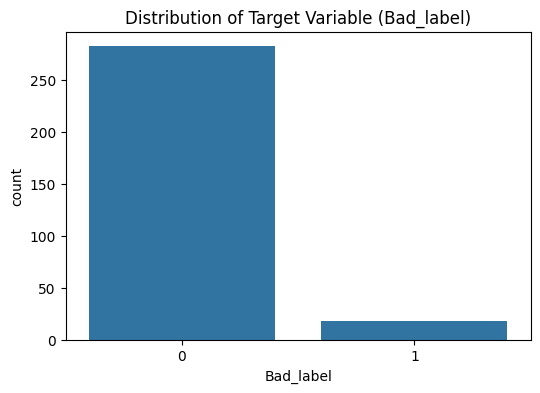

In [6]:
# ==========================================
# 4. Exploratory Data Analysis (EDA)
# ==========================================
# Fixed: 'default' changed to the correct column name 'Bad_label'
plt.figure(figsize=(6, 4))
sns.countplot(x='Bad_label', data=df)
plt.title('Distribution of Target Variable (Bad_label)')
plt.show()

# ==========================================

In [7]:
# 5. Feature Engineering
# ==========================================
le = LabelEncoder()

# Encode categorical (object) columns
for col in df.select_dtypes(include='object'):
    df[col] = le.fit_transform(df[col].astype(str))


In [9]:
# 6. Train-Test Split
# ==========================================
# Fixed: Drop the correct target column 'Bad_label'
X = df.drop('Bad_label', axis=1)
y = df['Bad_label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [10]:

# ==========================================
# 7. Feature Scaling
# ==========================================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [11]:
# ==========================================
# 8. Logistic Regression (Baseline)
# ==========================================
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

pred_prob_lr = lr.predict_proba(X_test)[:, 1]

auc_lr = roc_auc_score(y_test, pred_prob_lr)
gini_lr = 2 * auc_lr - 1

print("--- Logistic Regression Model ---")
print("AUC:", auc_lr)
print("Gini:", gini_lr)
print("-" * 30)

--- Logistic Regression Model ---
AUC: 0.7098214285714286
Gini: 0.4196428571428572
------------------------------


--- Random Forest Model ---
AUC: 0.5758928571428572
Random Forest Gini: 0.1517857142857144
------------------------------


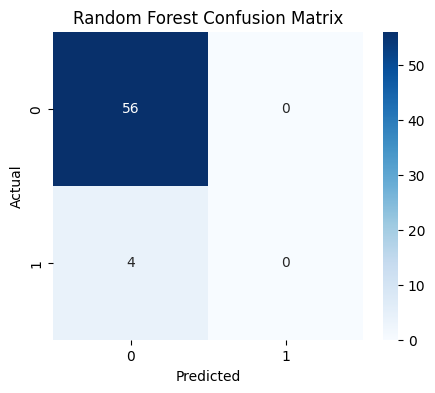

In [12]:
# ==========================================
# 9. Random Forest (Improve Benchmark)
# ==========================================
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

pred_prob_rf = rf.predict_proba(X_test)[:, 1]
pred_class_rf = rf.predict(X_test)

auc_rf = roc_auc_score(y_test, pred_prob_rf)
gini_rf = 2 * auc_rf - 1

print("--- Random Forest Model ---")
print("AUC:", auc_rf)
print("Random Forest Gini:", gini_rf)
print("-" * 30)

# Confusion Matrix for Random Forest
plt.figure(figsize=(5, 4))
cm = confusion_matrix(y_test, pred_class_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()



Top 15 Features by Gain:
    Feature     Gain
  dt_opened 0.068913
 feature_77 0.055851
  feature_7 0.052338
 feature_22 0.044553
 feature_44 0.041867
customer_no 0.036053
 feature_47 0.034423
 feature_24 0.032769
 feature_29 0.030884
 feature_66 0.029724
 feature_70 0.025858
 entry_time 0.025156
 feature_21 0.024295
 feature_20 0.023072
  feature_3 0.022964


<Figure size 1000x600 with 0 Axes>

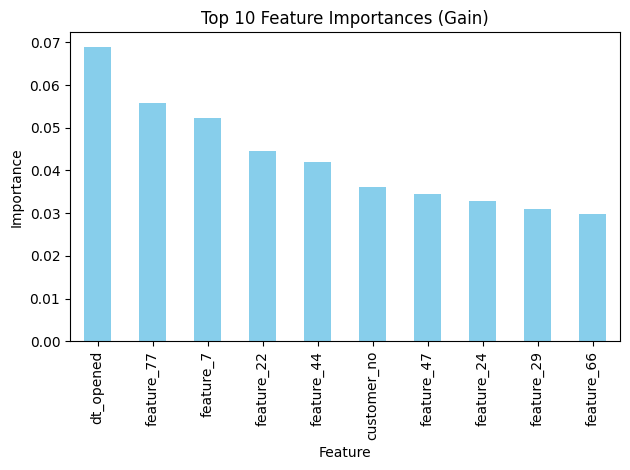

In [13]:
# ==========================================
# 10. Feature Matrix (Features selected with Gain)
# ==========================================
# Fulfilling Project Goal #2
feature_gain = pd.DataFrame({
    'Feature': X.columns,
    'Gain': rf.feature_importances_
}).sort_values(by='Gain', ascending=False)

print("\nTop 15 Features by Gain:")
print(feature_gain.head(15).to_string(index=False))

# Plot Top 10 Feature Importances
plt.figure(figsize=(10, 6))
feature_gain.set_index('Feature').head(10).plot(kind='bar', legend=False, color='skyblue')
plt.title('Top 10 Feature Importances (Gain)')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

In [14]:


# ==========================================
# 11. Model Evaluation - Rank Ordering
# ==========================================
# Fulfilling Project Goal #3
# Create a dataframe with actual labels and predicted probabilities
rank_df = pd.DataFrame({
    'Actual': y_test.values,
    'Probability': pred_prob_rf
})

# Sort by highest probability of being a "Bad" customer
rank_df = rank_df.sort_values(by='Probability', ascending=False)

# Divide into 10 Deciles
rank_df['Decile'] = pd.qcut(rank_df['Probability'].rank(method='first'), 10, labels=False)
# Adjust so Decile 1 represents the highest risk (top 10%)
rank_df['Decile'] = 10 - rank_df['Decile']

# Calculate rank ordering metrics per decile
rank_ordering = rank_df.groupby('Decile').agg(
    Total_Customers=('Actual', 'count'),
    Bad_Customers=('Actual', 'sum'),
    Min_Probability=('Probability', 'min'),
    Max_Probability=('Probability', 'max')
)

# Calculate the Bad Rate (Percentage of bad loans in that decile)
rank_ordering['Bad_Rate_Percentage'] = (rank_ordering['Bad_Customers'] / rank_ordering['Total_Customers']) * 100

print("\n--- Rank Ordering Table (Decile Analysis) ---")
print(rank_ordering)


--- Rank Ordering Table (Decile Analysis) ---
        Total_Customers  Bad_Customers  Min_Probability  Max_Probability  \
Decile                                                                     
1                     6              1            0.165            0.265   
2                     6              0            0.135            0.155   
3                     6              1            0.095            0.130   
4                     6              0            0.070            0.085   
5                     6              0            0.050            0.065   
6                     6              1            0.035            0.050   
7                     6              0            0.020            0.035   
8                     6              0            0.015            0.020   
9                     6              0            0.010            0.015   
10                    6              1            0.000            0.010   

        Bad_Rate_Percentage  
Decile    